# Calculating neuron tuning to stim1 identity

Plan is to look at neuron firing rate during stim1 encoding period
- calculate whether there is a significant difference between fr when stim1 is +1 versus -1

let's now add in the short delay (50) vs long delay (150)

(also adding some analyses excluding low-firing-rate neurons)

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *



2025-05-29 13:56:31.471667: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-29 13:56:31.481093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-29 13:56:31.491059: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-29 13:56:31.494049: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-29 13:56:31.502705: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = [50, 150]
condn_phrase = 'delay'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

## Seeing how consistent tuning is

### ex 1

#### tuning via rates

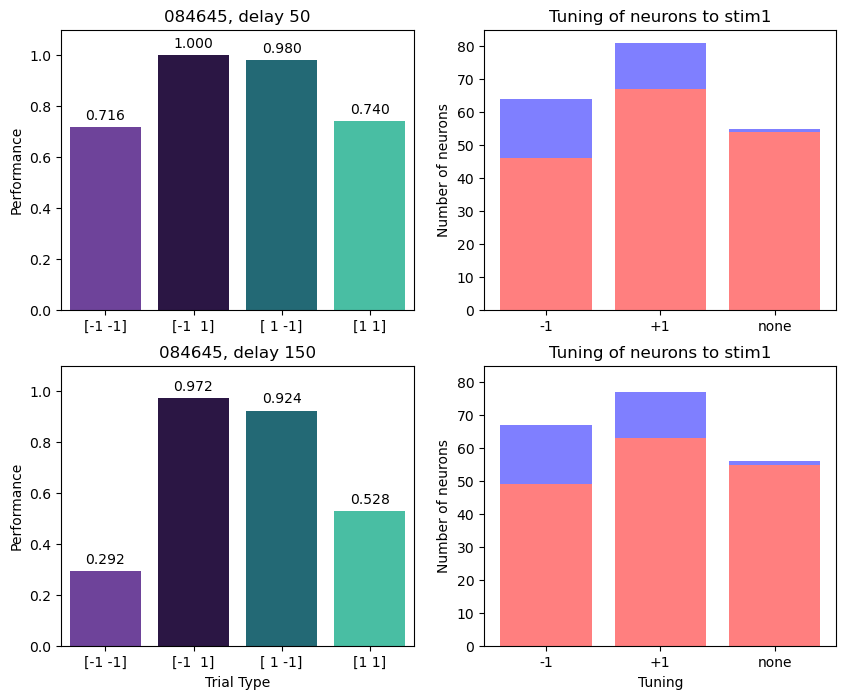

In [ ]:
# choose model 1 to visualize for now — tuning calc via rates
model_name = model_dirs[1]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(bhv)
tuning = np.zeros((200,2))
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    tuning[:,i] = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    sn.plot_stim1_tuning(tuning[:,i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


#### tuning via spikes

No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645


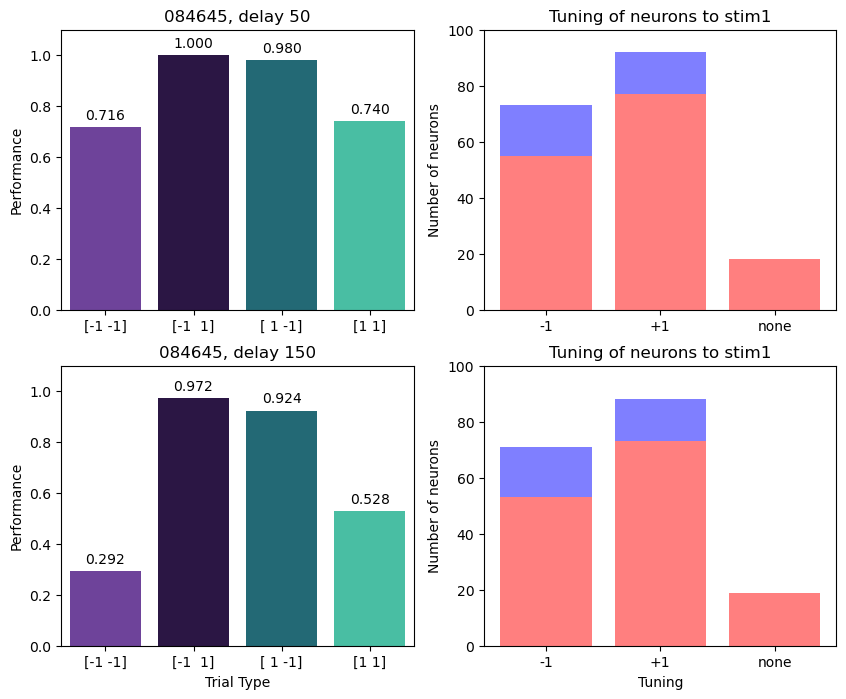

In [ ]:
# choose model 1 to visualize for now — tuning calc via spikes --- NEW, EXCLUDING LOW FR

importlib.reload(sn)
importlib.reload(ld)

model_name = model_dirs[1]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(sn)
tuning = []
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    spk_df = ld.load_neural_data(model_name, condn_phrase, condn_num, remove_lowfr=True,
                                                load_LFP=False, load_spikes=True, load_rates=False)['spk_df']
    tuning.append(sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num, spk_df=spk_df))
    exc_ind, inh_ind, exc_id, inh_id = ld.get_celltype_label(model_name, condn_phrase, condn_num, remove_lowfr=True)
    sn.plot_stim1_tuning(tuning[i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


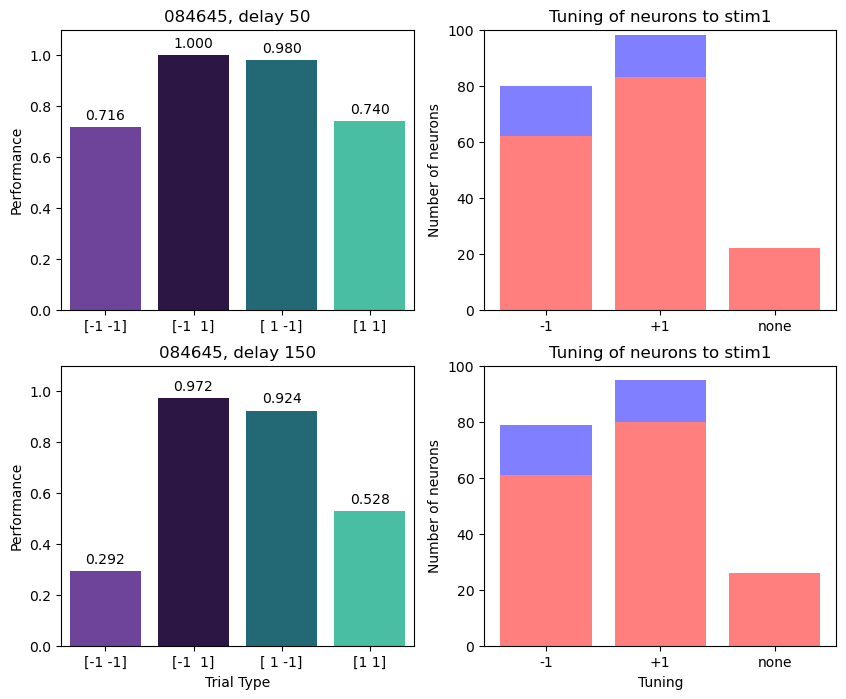

In [ ]:
# choose model 1 to visualize for now — tuning calc via spikes -- OLD, INCLUDING LOW FR
model_name = model_dirs[1]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(sn)
tuning = np.zeros((200,2))
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    tuning[:,i] = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    sn.plot_stim1_tuning(tuning[:,i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


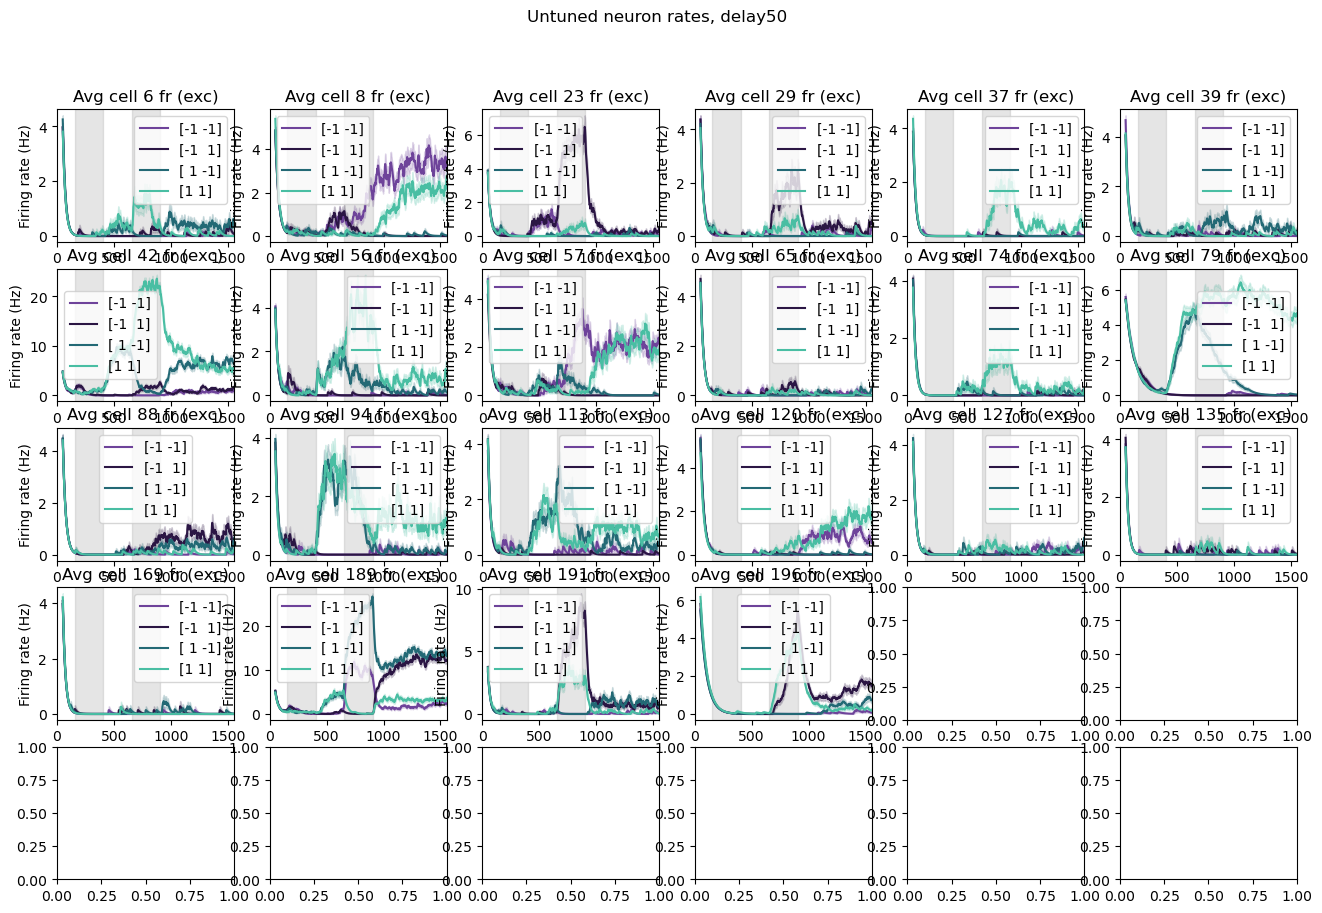

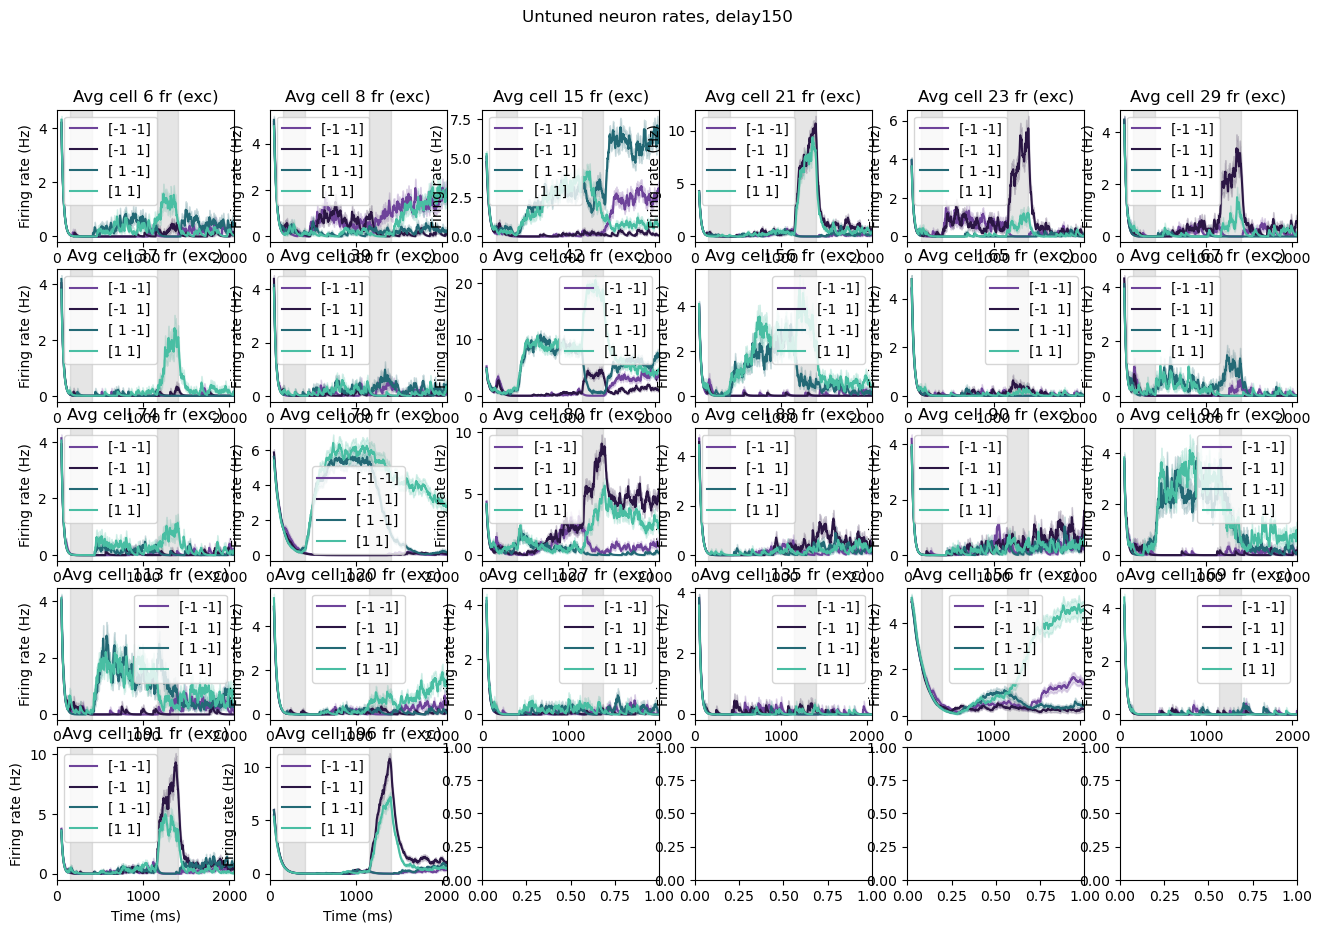

In [ ]:
# plot the untuned neurons

for i, condn_num in enumerate(delay):
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    fig, ax = plt.subplots(5,6,figsize=(16,10))
    ax = ax.flatten()
    untuned_idx = np.where(np.isnan(tuning[:,i]))[0]
    for j in range(len(untuned_idx)):
        sn.plot_neuron_rates(model_name, untuned_idx[j], condn_phrase, condn_num, 
                             rates_data=rates_data, ax=ax[j])
    plt.suptitle(f'Untuned neuron rates, {condn_phrase}{condn_num}')
    plt.show()

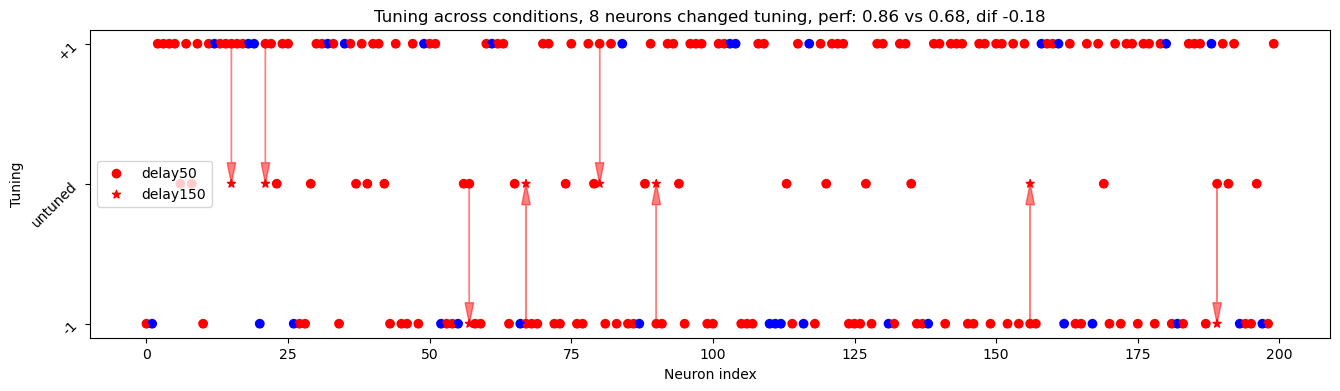

In [ ]:
# plot how each neuron's tuning has changed from short to long delay

colors = ['r' if i in exc_ind else 'b' for i in range(200)]
shapes = ['o','*']

tuning[np.where(np.isnan(tuning))] = 0
plt.figure(figsize=(16,4))
perfs = []
for i, condn_num in enumerate(delay):
    plt.scatter(np.arange(200), tuning[:,i], c=colors, label=f"{condn_phrase}{condn_num}",
                marker=shapes[i])
    _, perf = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    perfs.append(np.mean(perf))
flip = np.where(tuning[:,0] != tuning[:,1])[0]
for i in flip:
    # plt.plot([i,i], [tuning[i,0], tuning[i,1]], c='k', alpha=0.5)
    plt.arrow(i, tuning[i,0], 0, tuning[i,1]-tuning[i,0], length_includes_head=True,
              head_width=1.5, head_length=0.15, fc=colors[i], ec=colors[i], alpha=0.5)
plt.xlabel('Neuron index')
plt.ylabel('Tuning')
plt.yticks([-1,0,1], labels=['-1','untuned','+1'], rotation=45)
plt.title(f'Tuning across conditions, {len(flip)} neurons changed tuning, perf: {perfs[0]:.2f} vs {perfs[1]:.2f}, dif {perfs[1]-perfs[0]:.2f}')
plt.legend()
plt.show()


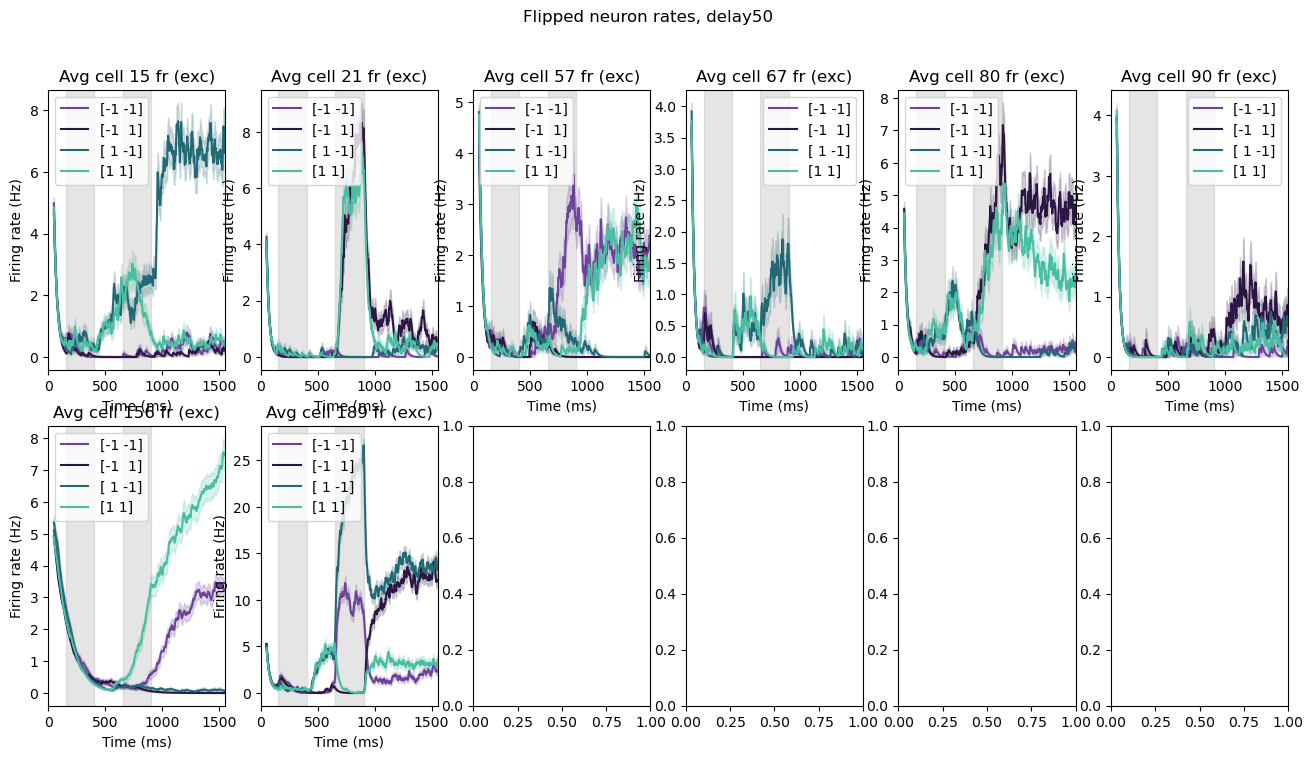

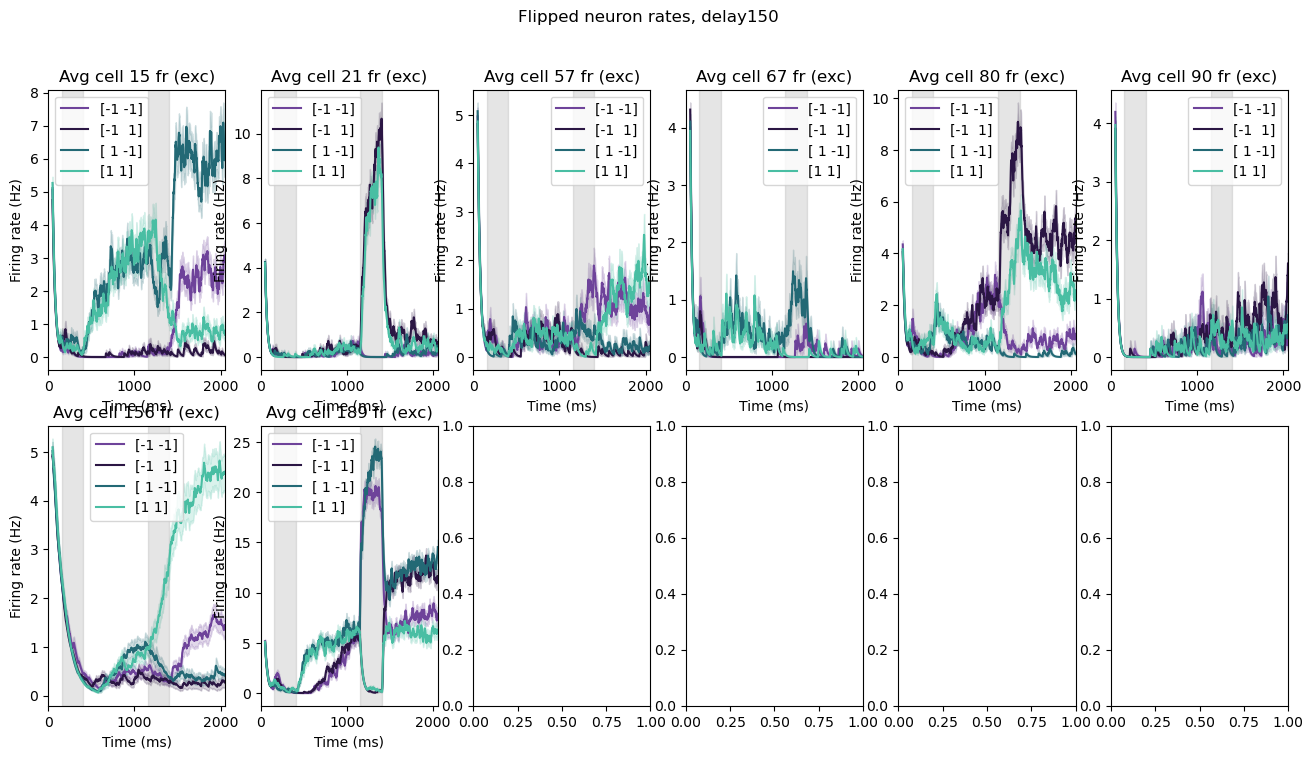

In [ ]:
# plot the rates that change

for i, condn_num in enumerate(delay):
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    fig, ax = plt.subplots(2,6,figsize=(16,8))
    ax = ax.flatten()
    for j in range(len(flip)):
        sn.plot_neuron_rates(model_name, flip[j], condn_phrase, condn_num, 
                             rates_data=rates_data, ax=ax[j])
    plt.suptitle(f'Flipped neuron rates, {condn_phrase}{condn_num}')
    plt.show()

#### tuning via spikes, correct

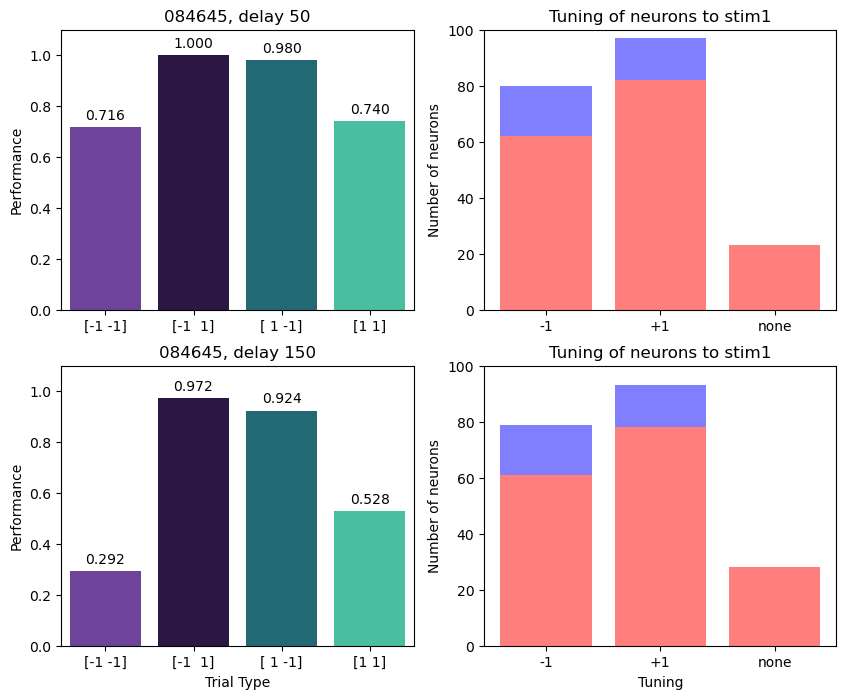

In [13]:
importlib.reload(sn)
# choose model 1 to visualize for now — tuning calc via spikes, only w correct trials
model_name = model_dirs[1]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(bhv)
tuning = np.zeros((200,2))
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    tuning[:,i] = sn.calc_stim1_tuning_spikes_corr(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    sn.plot_stim1_tuning(tuning[:,i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


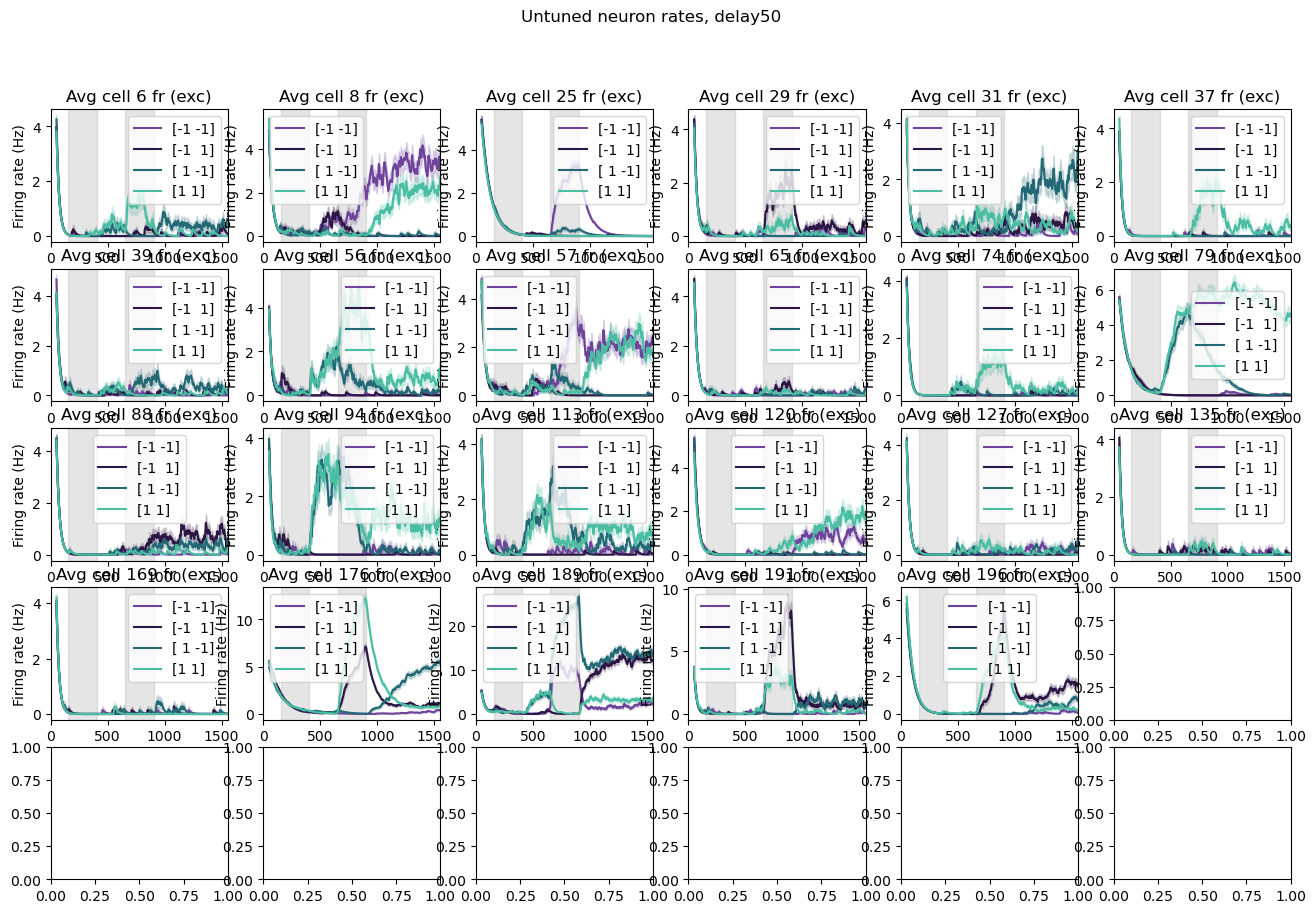

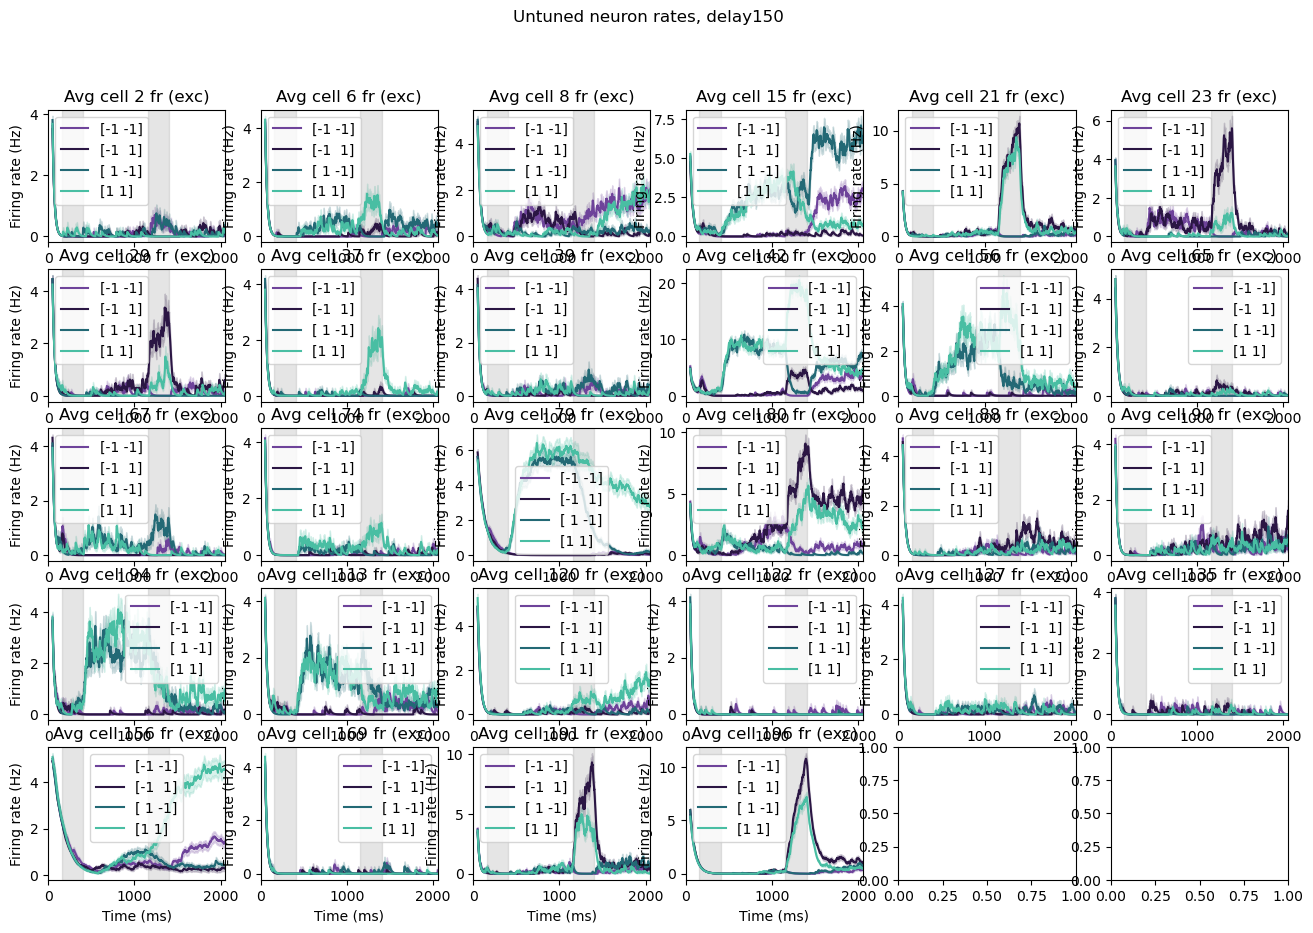

In [14]:
# plot the untuned neurons

for i, condn_num in enumerate(delay):
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    fig, ax = plt.subplots(5,6,figsize=(16,10))
    ax = ax.flatten()
    untuned_idx = np.where(np.isnan(tuning[:,i]))[0]
    for j in range(len(untuned_idx)):
        sn.plot_neuron_rates(model_name, untuned_idx[j], condn_phrase, condn_num, 
                             rates_data=rates_data, ax=ax[j])
    plt.suptitle(f'Untuned neuron rates, {condn_phrase}{condn_num}')
    plt.show()

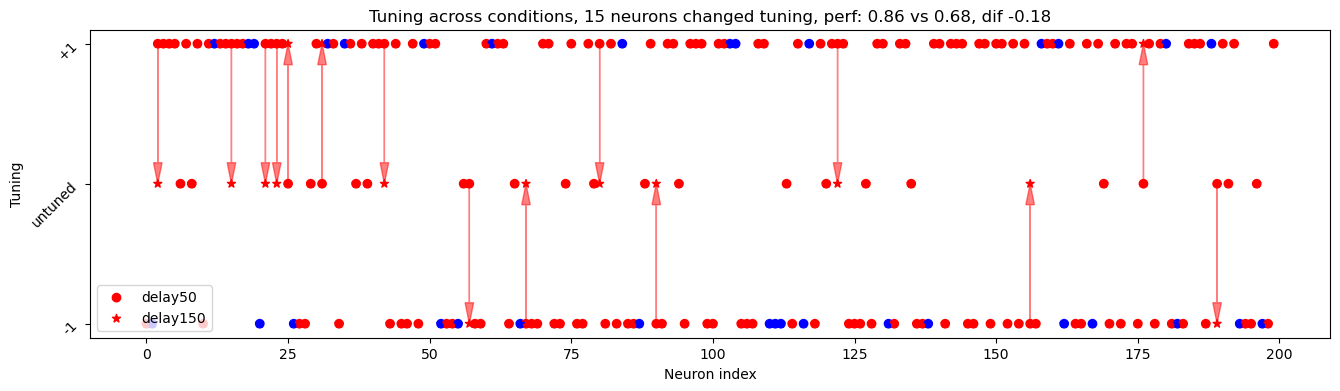

In [7]:
# plot how each neuron's tuning has changed from short to long delay

colors = ['r' if i in exc_ind else 'b' for i in range(200)]
shapes = ['o','*']

tuning[np.where(np.isnan(tuning))] = 0
plt.figure(figsize=(16,4))
perfs = []
for i, condn_num in enumerate(delay):
    plt.scatter(np.arange(200), tuning[:,i], c=colors, label=f"{condn_phrase}{condn_num}",
                marker=shapes[i])
    _, perf = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    perfs.append(np.mean(perf))
flip = np.where(tuning[:,0] != tuning[:,1])[0]
for i in flip:
    # plt.plot([i,i], [tuning[i,0], tuning[i,1]], c='k', alpha=0.5)
    plt.arrow(i, tuning[i,0], 0, tuning[i,1]-tuning[i,0], length_includes_head=True,
              head_width=1.5, head_length=0.15, fc=colors[i], ec=colors[i], alpha=0.5)
plt.xlabel('Neuron index')
plt.ylabel('Tuning')
plt.yticks([-1,0,1], labels=['-1','untuned','+1'], rotation=45)
plt.title(f'Tuning across conditions, {len(flip)} neurons changed tuning, perf: {perfs[0]:.2f} vs {perfs[1]:.2f}, dif {perfs[1]-perfs[0]:.2f}')
plt.legend()
plt.show()


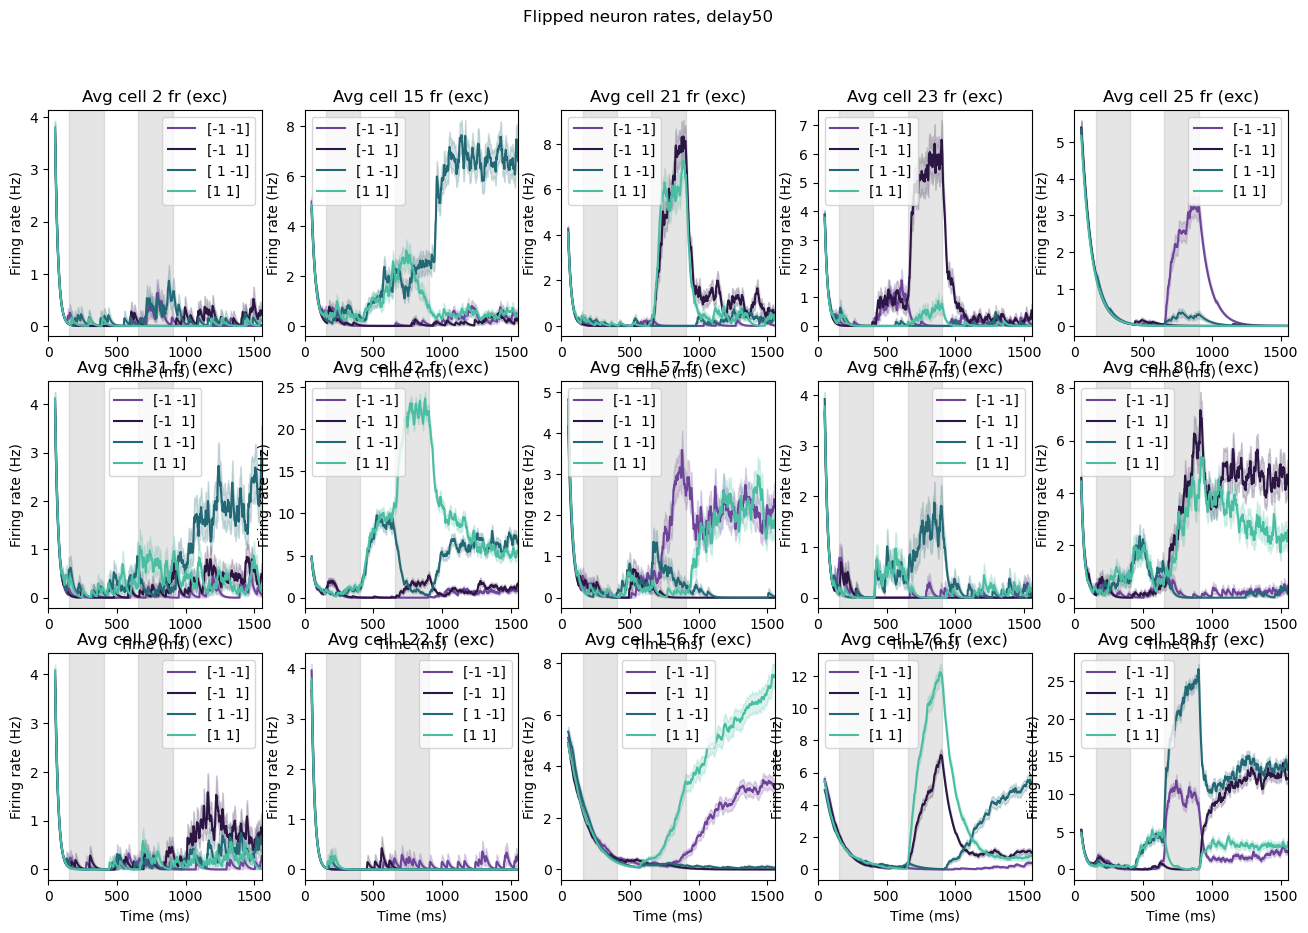

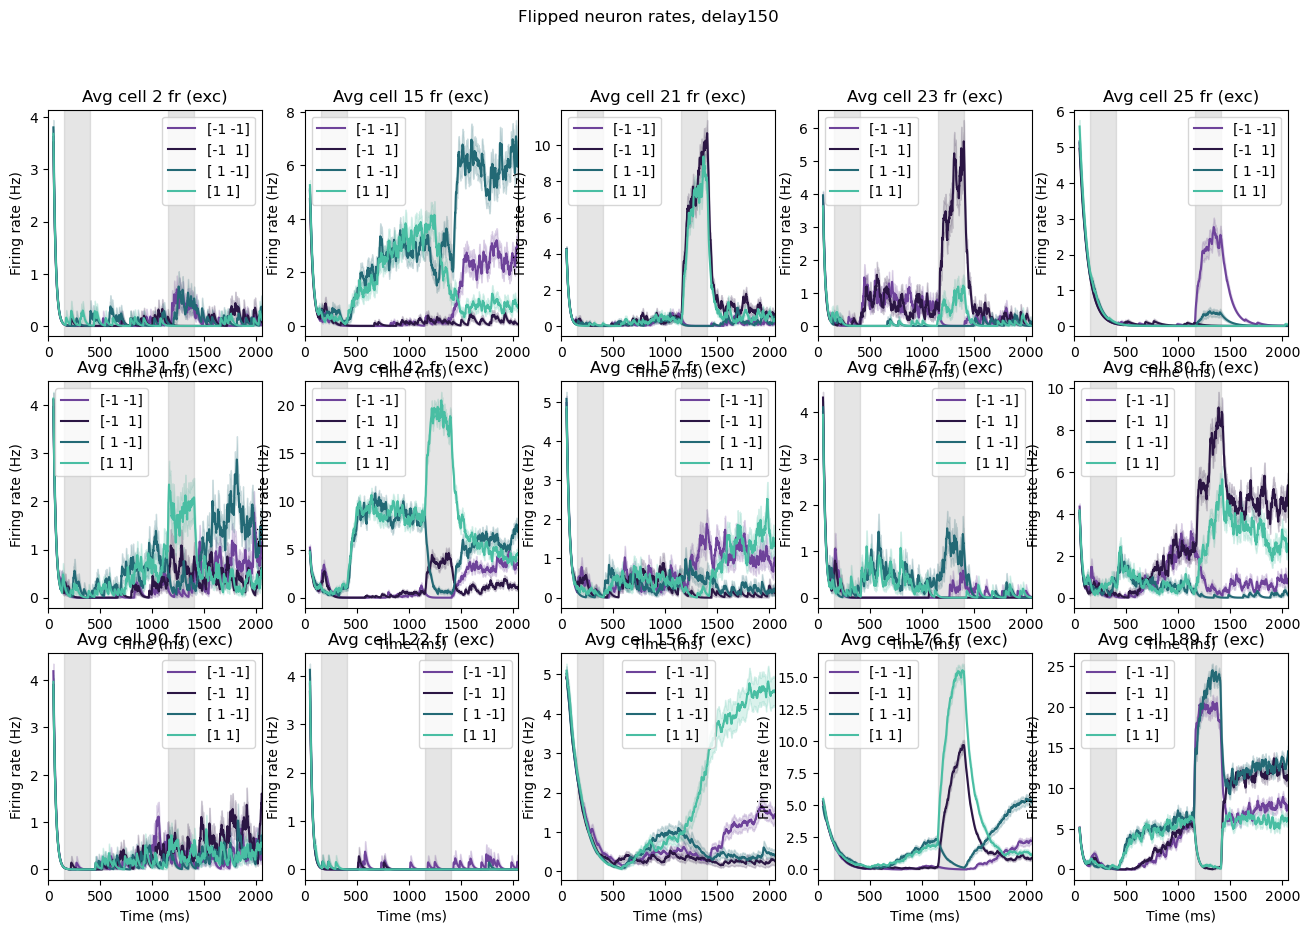

In [9]:
# plot the rates that change

for i, condn_num in enumerate(delay):
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    fig, ax = plt.subplots(3,5,figsize=(16,10))
    ax = ax.flatten()
    for j in range(len(flip)):
        sn.plot_neuron_rates(model_name, flip[j], condn_phrase, condn_num, 
                             rates_data=rates_data, ax=ax[j])
    plt.suptitle(f'Flipped neuron rates, {condn_phrase}{condn_num}')
    plt.show()

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/single_neuron_utils.py:404: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  # plot firing rate for correct trials


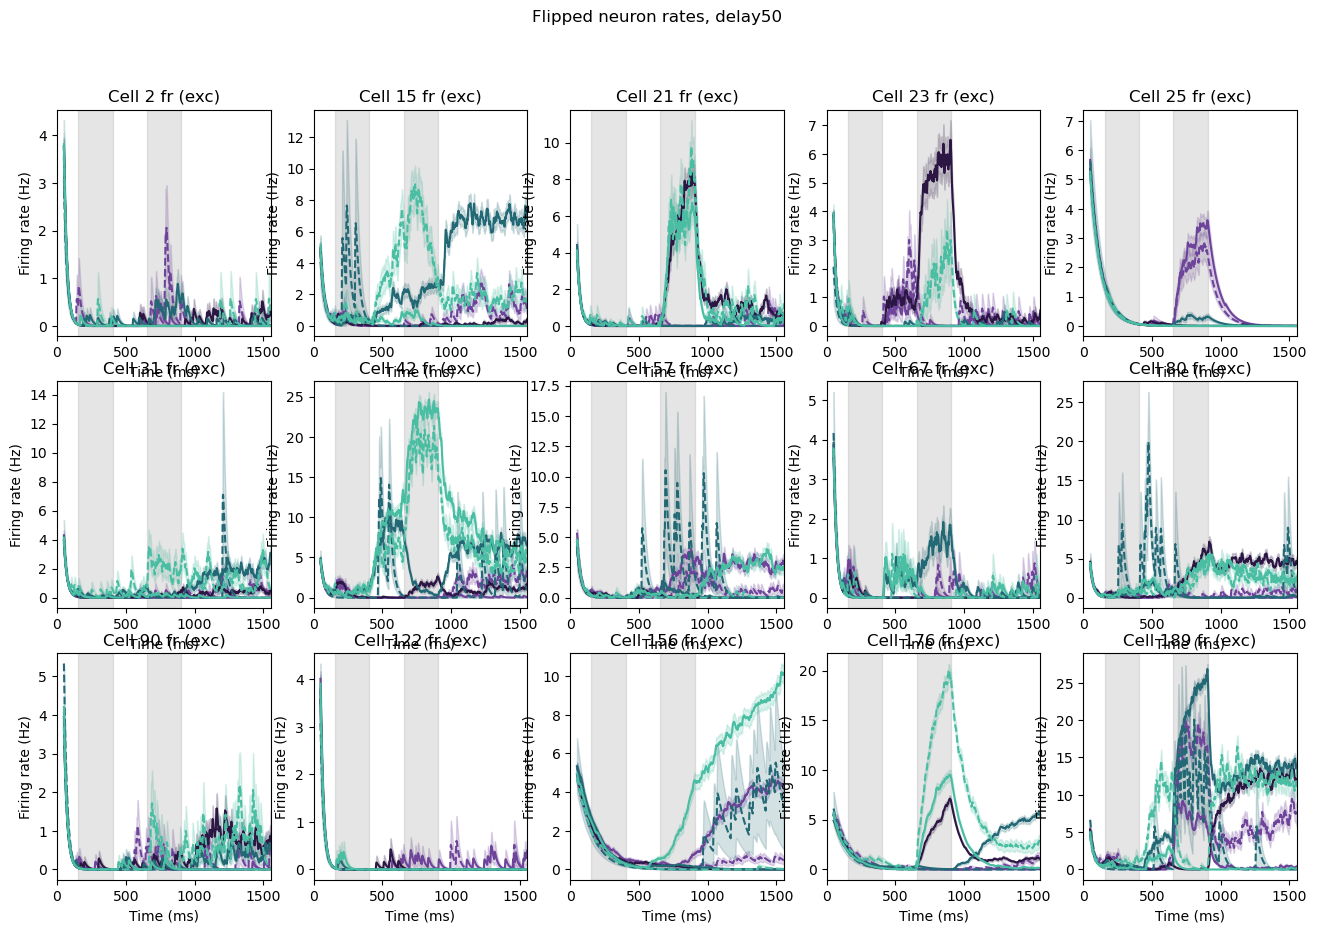

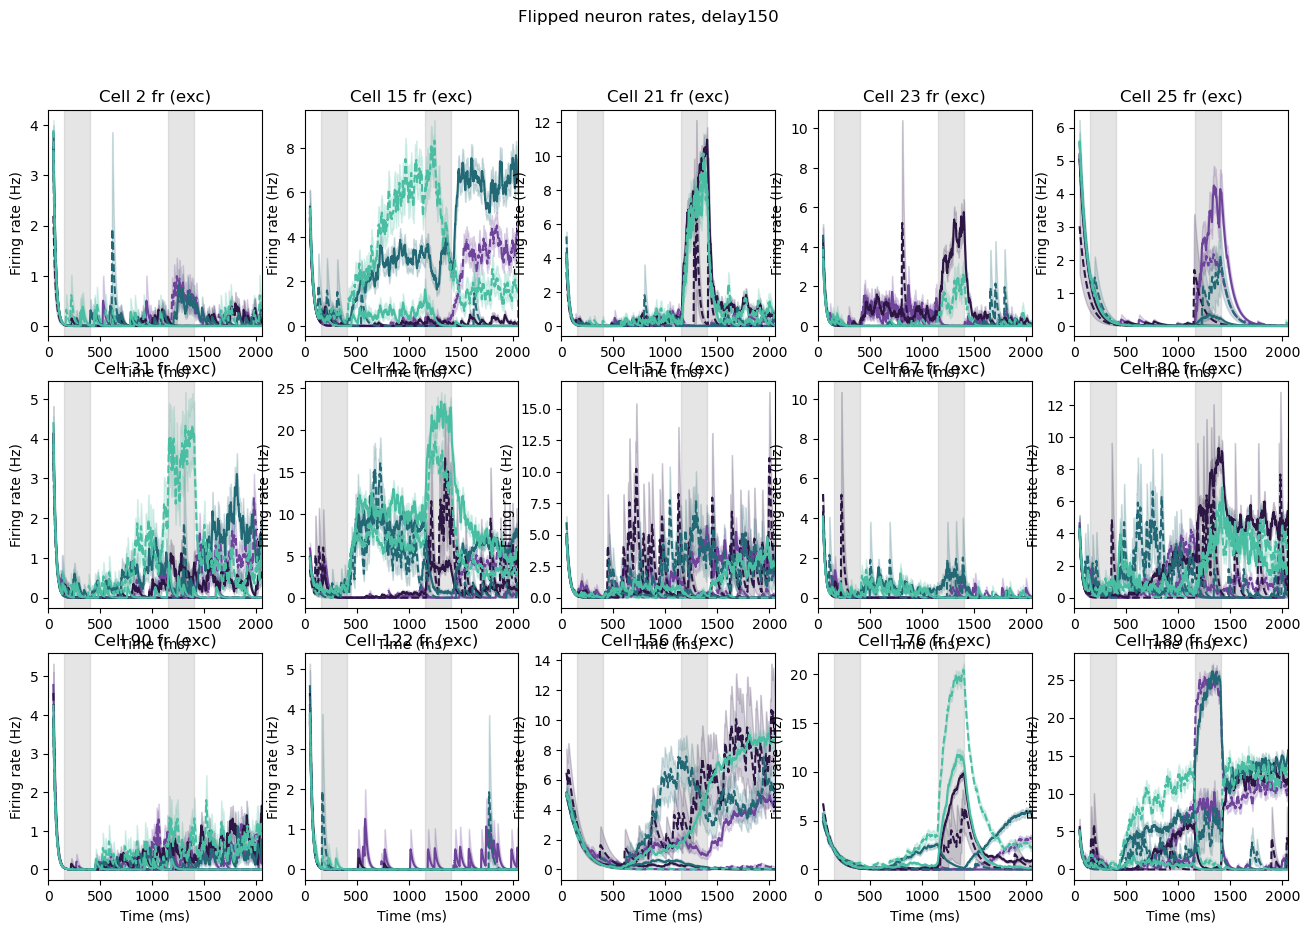

In [10]:
# plot the rates that change

for i, condn_num in enumerate(delay):
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    fig, ax = plt.subplots(3,5,figsize=(16,10))
    ax = ax.flatten()
    for j in range(len(flip)):
        sn.plot_neuron_rates_by_acc(model_name, flip[j], condn_phrase, condn_num, 
                             rates_data=rates_data, ax=ax[j])
    plt.suptitle(f'Flipped neuron rates, {condn_phrase}{condn_num}')
    plt.show()

### ex 2

#### tuning via rates

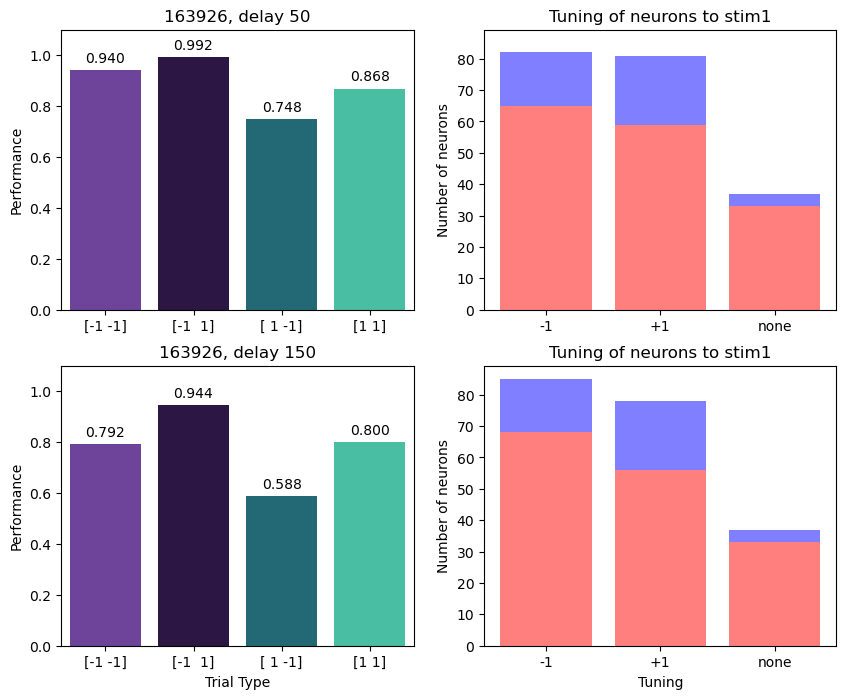

In [6]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926'

tuning = np.zeros((200,2))
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    tuning[:,i] = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    sn.plot_stim1_tuning(tuning[:,i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


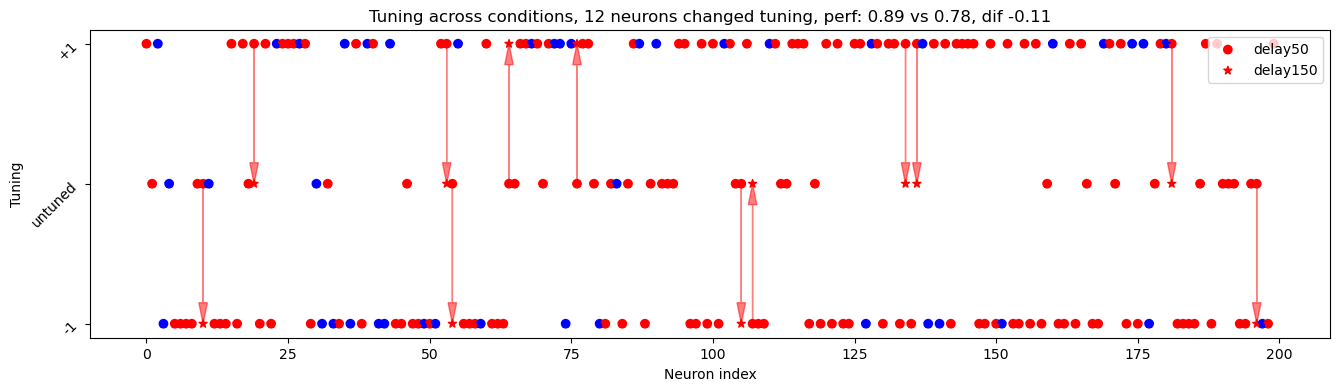

In [7]:
# plot how each neuron's tuning has changed

colors = ['r' if i in exc_ind else 'b' for i in range(200)]
shapes = ['o','*']

tuning[np.where(np.isnan(tuning))] = 0
plt.figure(figsize=(16,4))
perfs = []
for i, condn_num in enumerate(delay):
    plt.scatter(np.arange(200), tuning[:,i], c=colors, label=f"{condn_phrase}{condn_num}",
                marker=shapes[i])
    _, perf = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    perfs.append(np.mean(perf))
flip = np.where(tuning[:,0] != tuning[:,1])[0]
for i in flip:
    # plt.plot([i,i], [tuning[i,0], tuning[i,1]], c='k', alpha=0.5)
    plt.arrow(i, tuning[i,0], 0, tuning[i,1]-tuning[i,0], length_includes_head=True,
              head_width=1.5, head_length=0.15, fc=colors[i], ec=colors[i], alpha=0.5)
plt.xlabel('Neuron index')
plt.ylabel('Tuning')
plt.yticks([-1,0,1], labels=['-1','untuned','+1'], rotation=45)
plt.title(f'Tuning across conditions, {len(flip)} neurons changed tuning, perf: {perfs[0]:.2f} vs {perfs[1]:.2f}, dif {perfs[1]-perfs[0]:.2f}')
plt.legend()
plt.show()


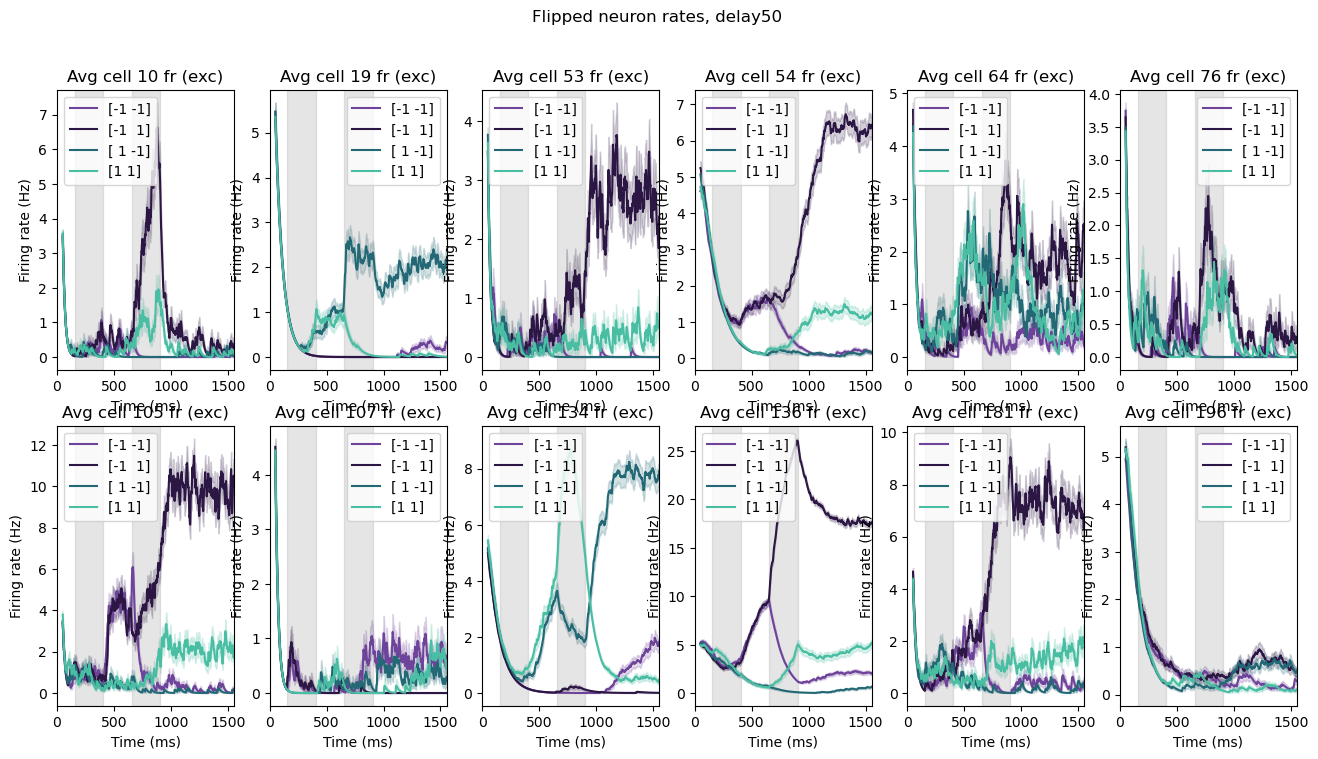

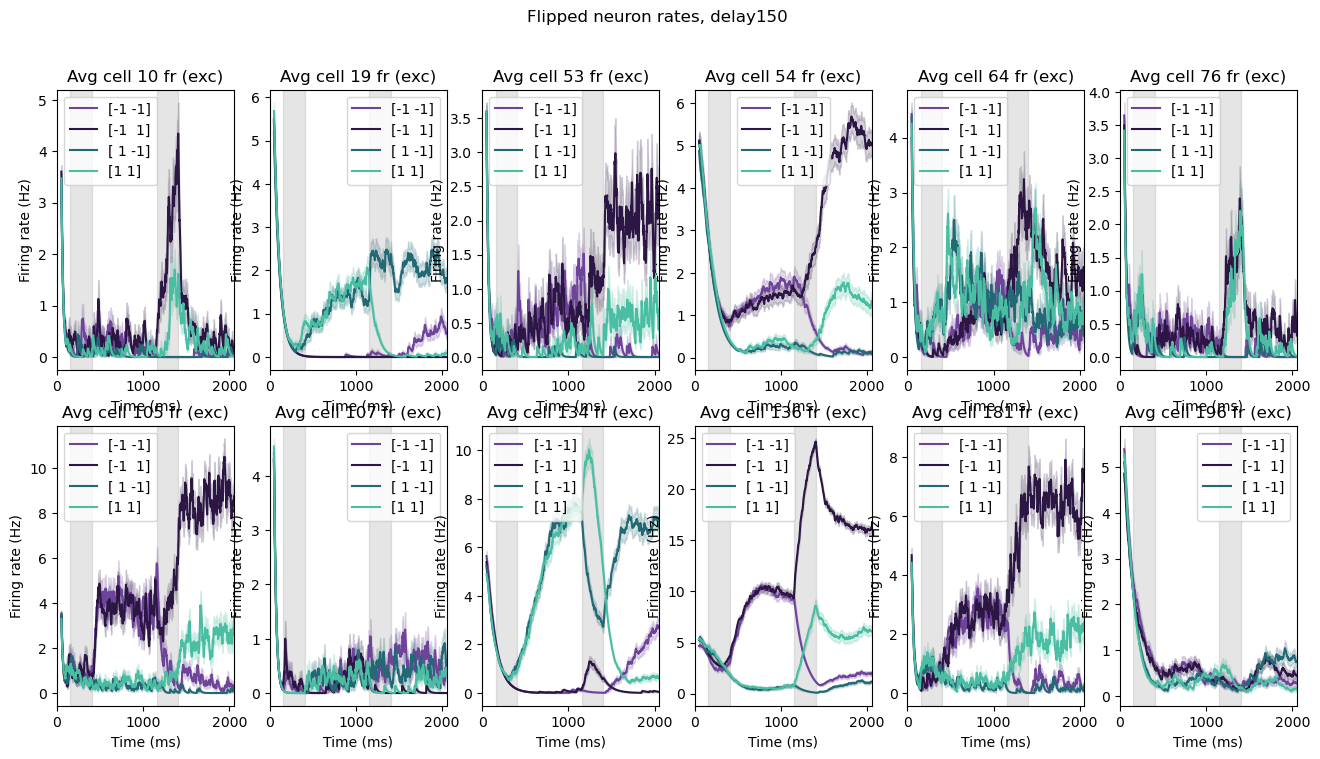

In [15]:
# plot the rates that change

for i, condn_num in enumerate(delay):
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    fig, ax = plt.subplots(2,6,figsize=(16,8))
    ax = ax.flatten()
    for j in range(len(flip)):
        sn.plot_neuron_rates(model_name, flip[j], condn_phrase, condn_num, 
                             rates_data=rates_data, ax=ax[j])
    plt.suptitle(f'Flipped neuron rates, {condn_phrase}{condn_num}')
    plt.show()

#### tuning via spikes correct

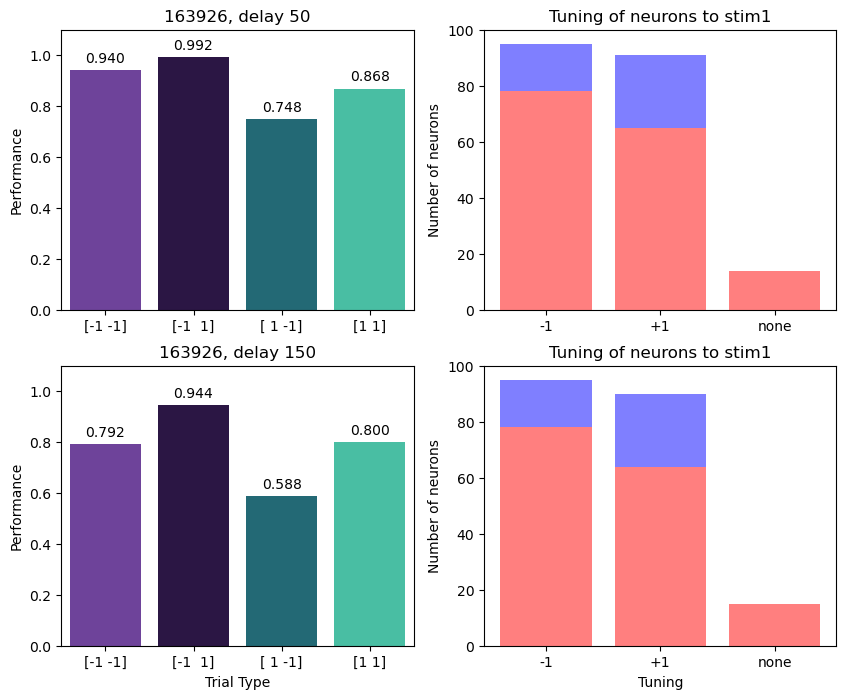

In [4]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926'

tuning = np.zeros((200,2))
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    tuning[:,i] = sn.calc_stim1_tuning_spikes_corr(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    sn.plot_stim1_tuning(tuning[:,i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


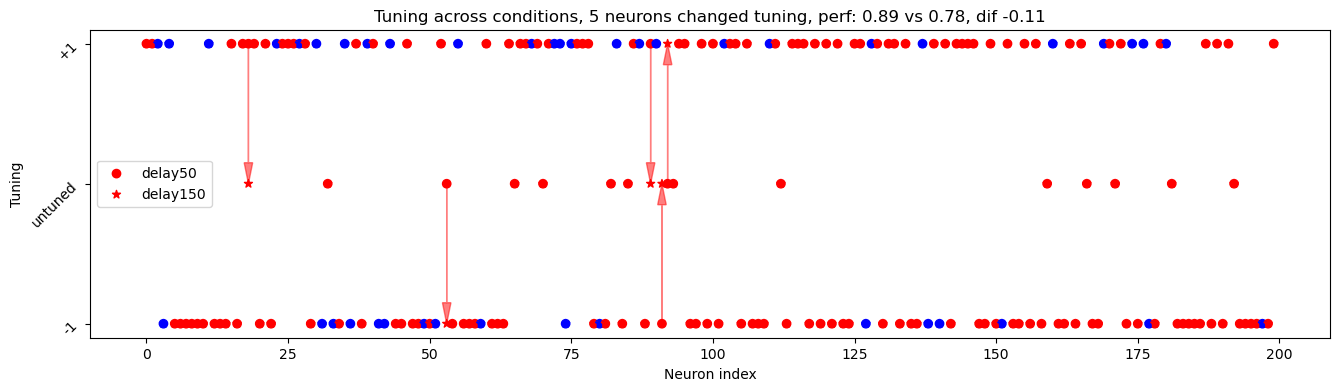

In [5]:
# plot how each neuron's tuning has changed

colors = ['r' if i in exc_ind else 'b' for i in range(200)]
shapes = ['o','*']

tuning[np.where(np.isnan(tuning))] = 0
plt.figure(figsize=(16,4))
perfs = []
for i, condn_num in enumerate(delay):
    plt.scatter(np.arange(200), tuning[:,i], c=colors, label=f"{condn_phrase}{condn_num}",
                marker=shapes[i])
    _, perf = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    perfs.append(np.mean(perf))
flip = np.where(tuning[:,0] != tuning[:,1])[0]
for i in flip:
    # plt.plot([i,i], [tuning[i,0], tuning[i,1]], c='k', alpha=0.5)
    plt.arrow(i, tuning[i,0], 0, tuning[i,1]-tuning[i,0], length_includes_head=True,
              head_width=1.5, head_length=0.15, fc=colors[i], ec=colors[i], alpha=0.5)
plt.xlabel('Neuron index')
plt.ylabel('Tuning')
plt.yticks([-1,0,1], labels=['-1','untuned','+1'], rotation=45)
plt.title(f'Tuning across conditions, {len(flip)} neurons changed tuning, perf: {perfs[0]:.2f} vs {perfs[1]:.2f}, dif {perfs[1]-perfs[0]:.2f}')
plt.legend()
plt.show()


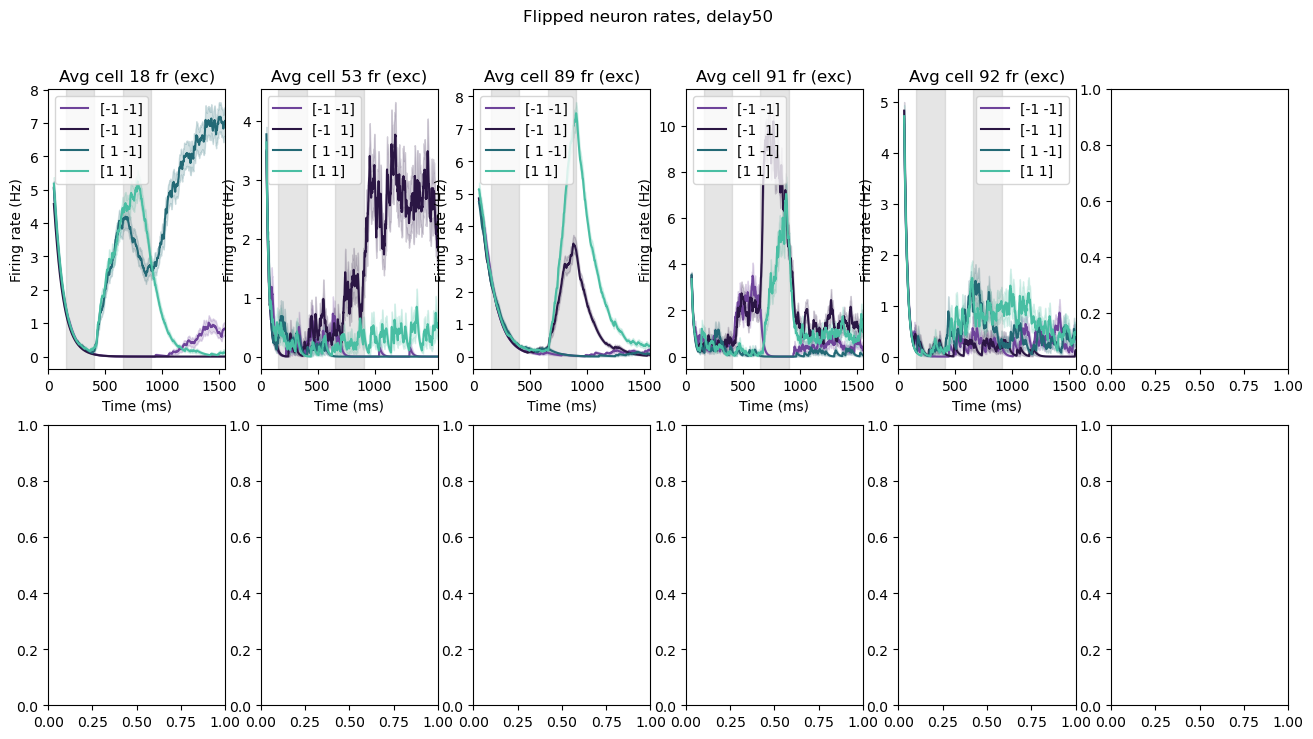

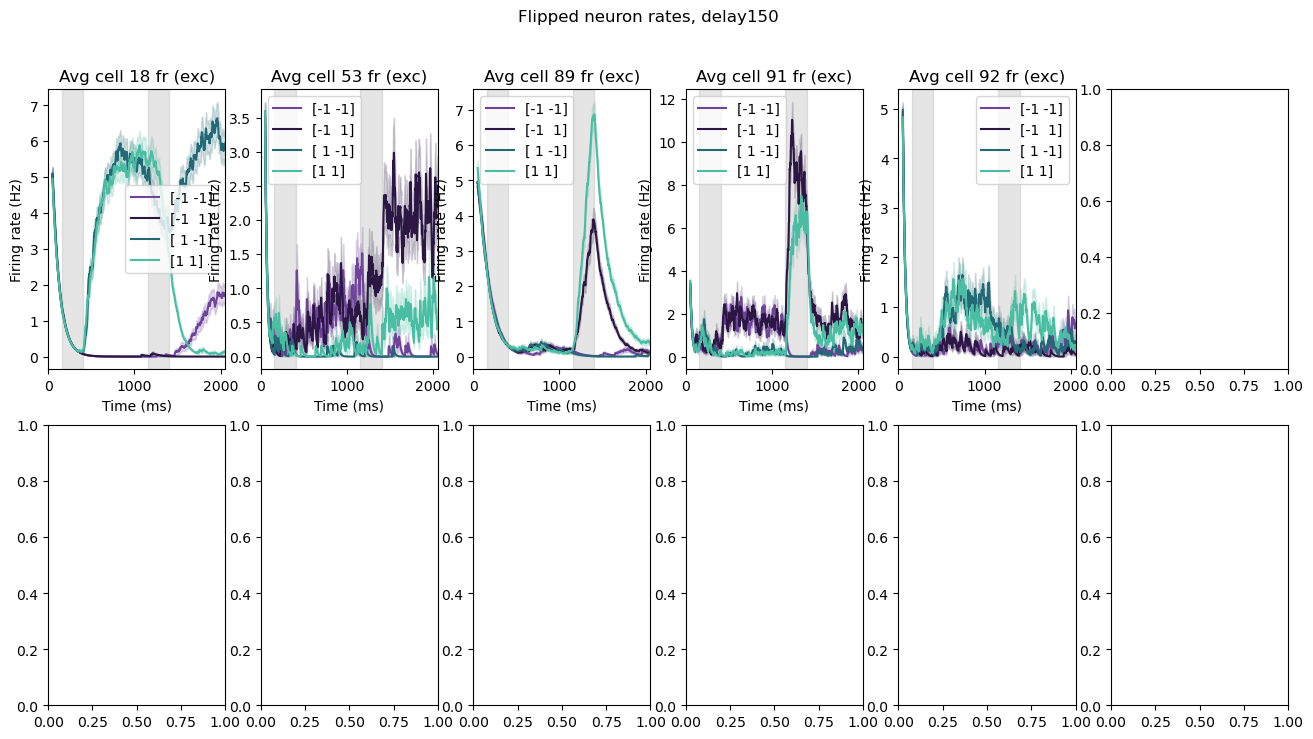

Neuron 18 tuning: 1.00 vs 0.00
Neuron 53 tuning: 0.00 vs -1.00
Neuron 89 tuning: 1.00 vs 0.00
Neuron 91 tuning: -1.00 vs 0.00
Neuron 92 tuning: 0.00 vs 1.00


In [6]:
# plot the rates that change

for i, condn_num in enumerate(delay):
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    fig, ax = plt.subplots(2,6,figsize=(16,8))
    ax = ax.flatten()
    for j in range(len(flip)):
        sn.plot_neuron_rates(model_name, flip[j], condn_phrase, condn_num, 
                             rates_data=rates_data, ax=ax[j])
    plt.suptitle(f'Flipped neuron rates, {condn_phrase}{condn_num}')
    plt.show()

for i in flip:
    print(f'Neuron {i} tuning: {tuning[i,0]:.2f} vs {tuning[i,1]:.2f}')

### ex 3

#### tuning from rates

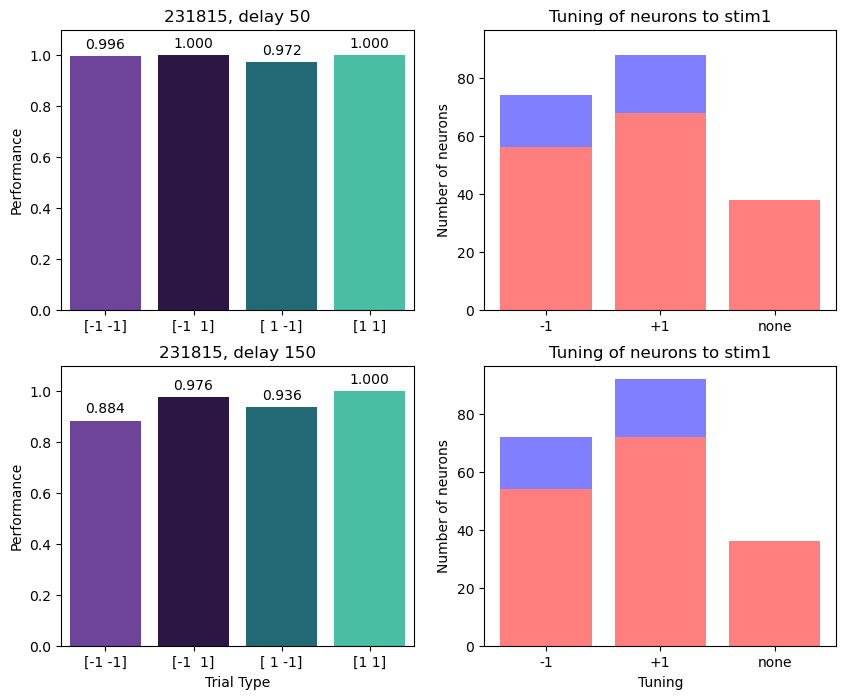

In [47]:
# choose model 1 to visualize for now
model_name = model_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(bhv)
tuning = np.zeros((200,2))
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    tuning[:,i] = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    sn.plot_stim1_tuning(tuning[:,i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


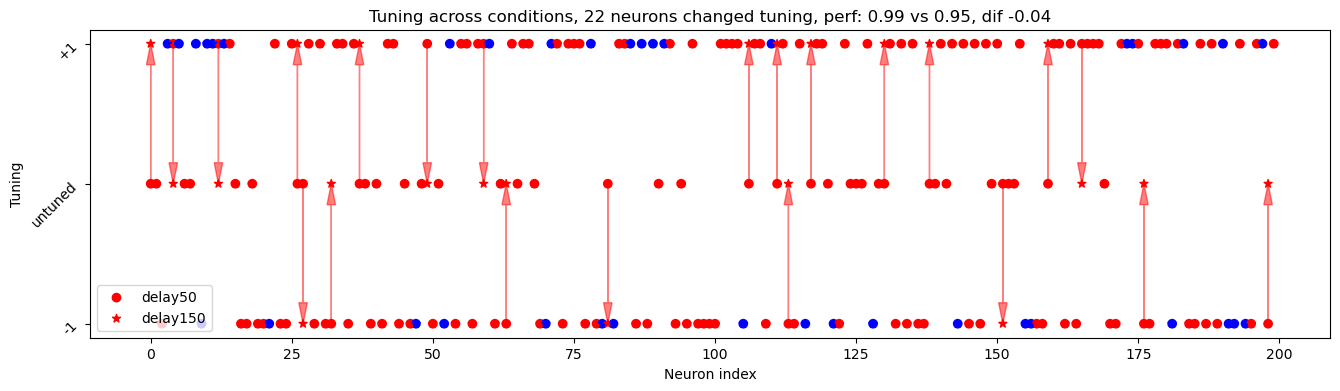

In [50]:
# plot how each neuron's tuning has changed

colors = ['r' if i in exc_ind else 'b' for i in range(200)]
shapes = ['o','*']

tuning[np.where(np.isnan(tuning))] = 0
plt.figure(figsize=(16,4))
perfs = []
for i, condn_num in enumerate(delay):
    plt.scatter(np.arange(200), tuning[:,i], c=colors, label=f"{condn_phrase}{condn_num}",
                marker=shapes[i])
    _, perf = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    perfs.append(np.mean(perf))
flip = np.where(tuning[:,0] != tuning[:,1])[0]
for i in flip:
    # plt.plot([i,i], [tuning[i,0], tuning[i,1]], c='k', alpha=0.5)
    plt.arrow(i, tuning[i,0], 0, tuning[i,1]-tuning[i,0], length_includes_head=True,
              head_width=1.5, head_length=0.15, fc=colors[i], ec=colors[i], alpha=0.5)
plt.xlabel('Neuron index')
plt.ylabel('Tuning')
plt.yticks([-1,0,1], labels=['-1','untuned','+1'], rotation=45)
plt.title(f'Tuning across conditions, {len(flip)} neurons changed tuning, perf: {perfs[0]:.2f} vs {perfs[1]:.2f}, dif {perfs[1]-perfs[0]:.2f}')
plt.legend()
plt.show()


#### tuning from spikes corr

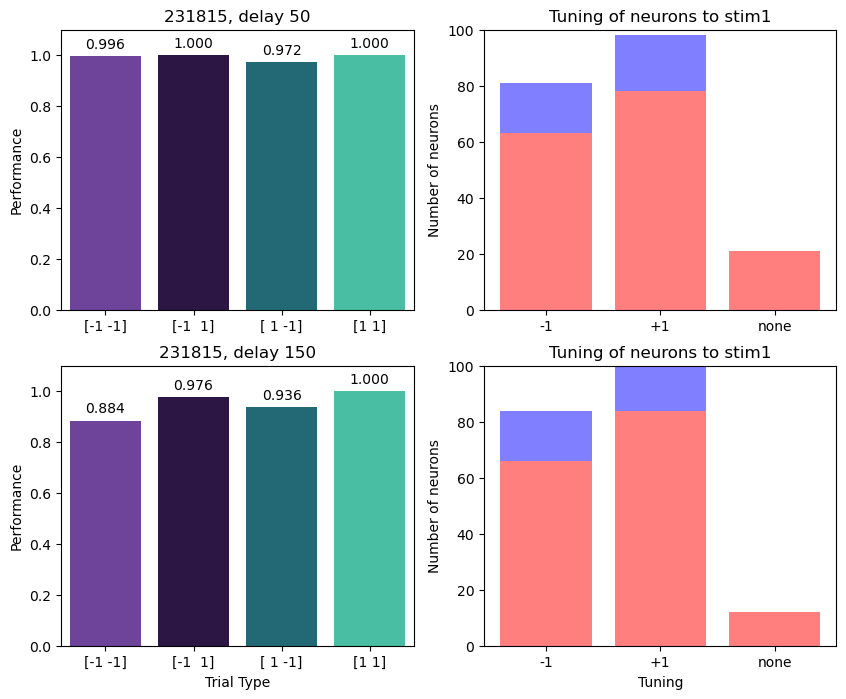

In [7]:
# choose model 1 to visualize for now
model_name = model_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(bhv)
tuning = np.zeros((200,2))
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    tuning[:,i] = sn.calc_stim1_tuning_spikes_corr(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    sn.plot_stim1_tuning(tuning[:,i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


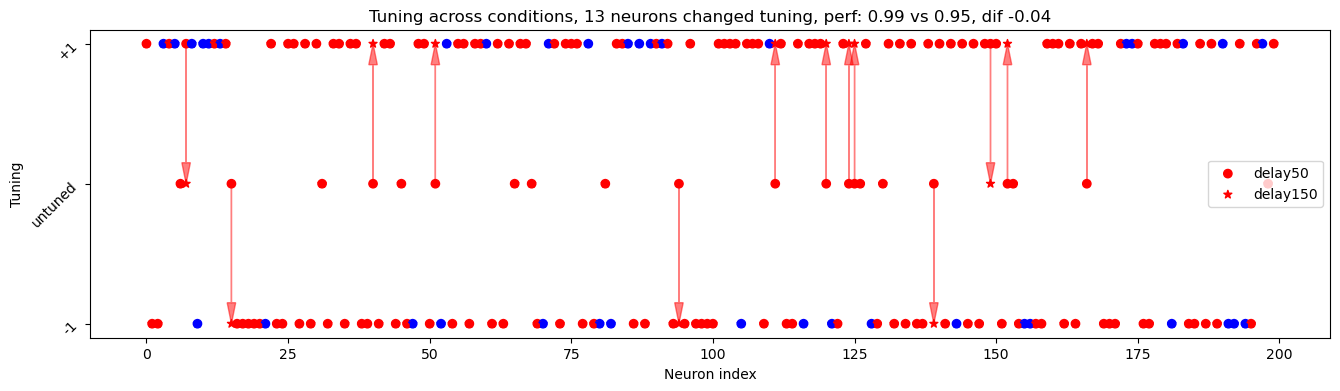

In [8]:
# plot how each neuron's tuning has changed

colors = ['r' if i in exc_ind else 'b' for i in range(200)]
shapes = ['o','*']

tuning[np.where(np.isnan(tuning))] = 0
plt.figure(figsize=(16,4))
perfs = []
for i, condn_num in enumerate(delay):
    plt.scatter(np.arange(200), tuning[:,i], c=colors, label=f"{condn_phrase}{condn_num}",
                marker=shapes[i])
    _, perf = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    perfs.append(np.mean(perf))
flip = np.where(tuning[:,0] != tuning[:,1])[0]
for i in flip:
    # plt.plot([i,i], [tuning[i,0], tuning[i,1]], c='k', alpha=0.5)
    plt.arrow(i, tuning[i,0], 0, tuning[i,1]-tuning[i,0], length_includes_head=True,
              head_width=1.5, head_length=0.15, fc=colors[i], ec=colors[i], alpha=0.5)
plt.xlabel('Neuron index')
plt.ylabel('Tuning')
plt.yticks([-1,0,1], labels=['-1','untuned','+1'], rotation=45)
plt.title(f'Tuning across conditions, {len(flip)} neurons changed tuning, perf: {perfs[0]:.2f} vs {perfs[1]:.2f}, dif {perfs[1]-perfs[0]:.2f}')
plt.legend()
plt.show()


IndexError: index 12 is out of bounds for axis 0 with size 12

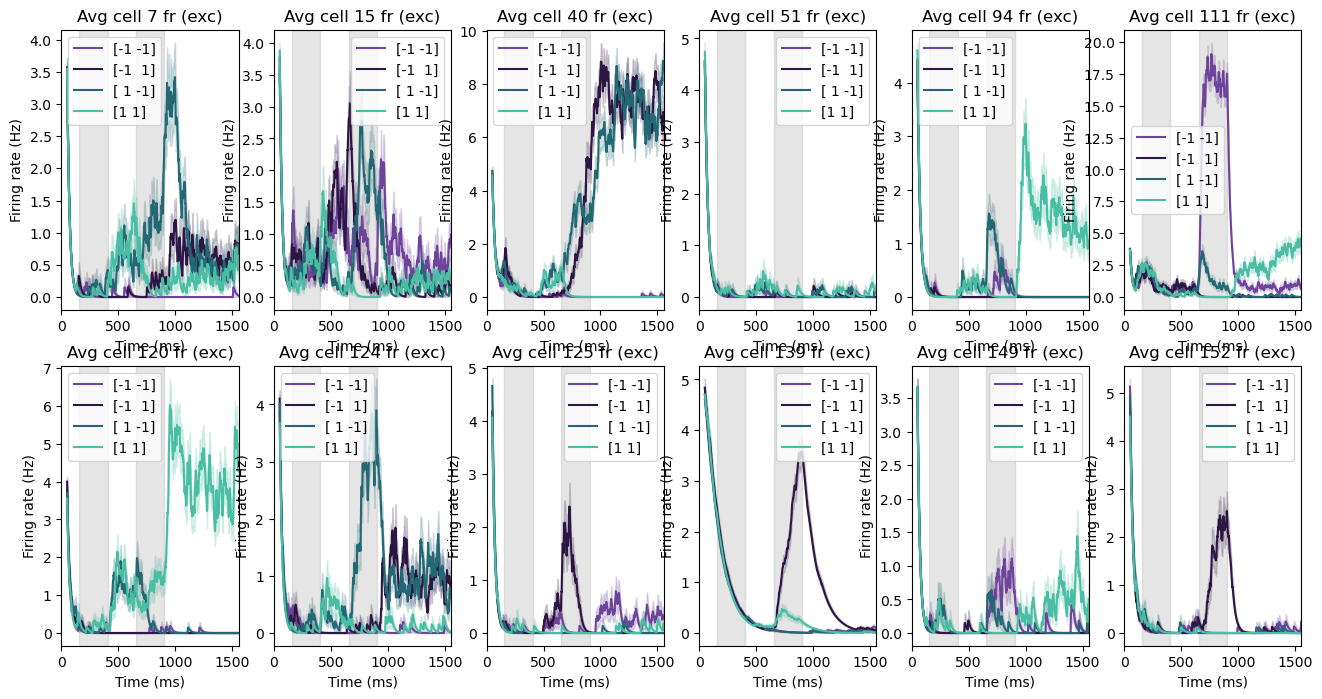

In [9]:
# plot the rates that change

for i, condn_num in enumerate(delay):
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    fig, ax = plt.subplots(2,6,figsize=(16,8))
    ax = ax.flatten()
    for j in range(len(flip)):
        sn.plot_neuron_rates(model_name, flip[j], condn_phrase, condn_num, 
                             rates_data=rates_data, ax=ax[j])
    plt.suptitle(f'Flipped neuron rates, {condn_phrase}{condn_num}')
    plt.show()

for i in flip:
    print(f'Neuron {i} tuning: {tuning[i,0]:.2f} vs {tuning[i,1]:.2f}')

## Firing rate from tuning

### Plot spikes from neuron groups based on tuning in diff trials

In [4]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926'
condn_num = delay[0]
_, spk_df, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=True, load_rates=False)
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)

In [5]:
def double_sort(sort1, sort2):
    """
    Sorts two arrays by the first, then the second.
    """
    sort1 = np.array(sort1)
    sort2 = np.array(sort2)
    ind = np.lexsort((sort2, sort1))
    return sort1[ind], sort2[ind], ind

In [6]:
exc_ind, inh_ind = ld.get_celltype_label(model_name)
exc_bool = np.zeros(200)
exc_bool[exc_ind] = 1

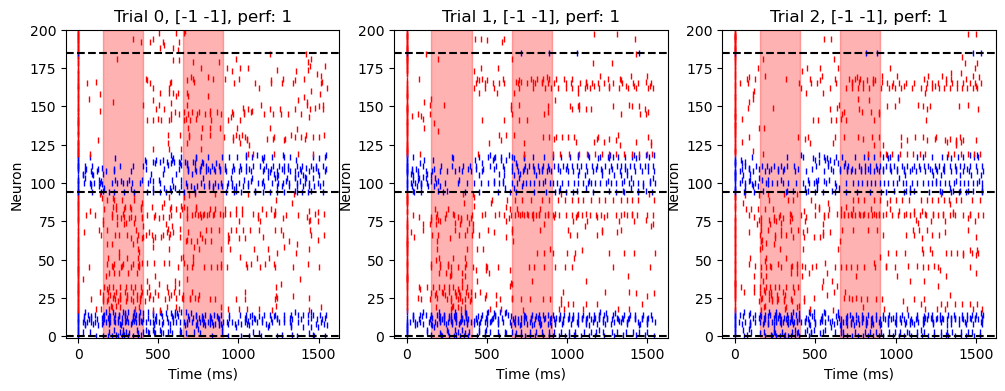

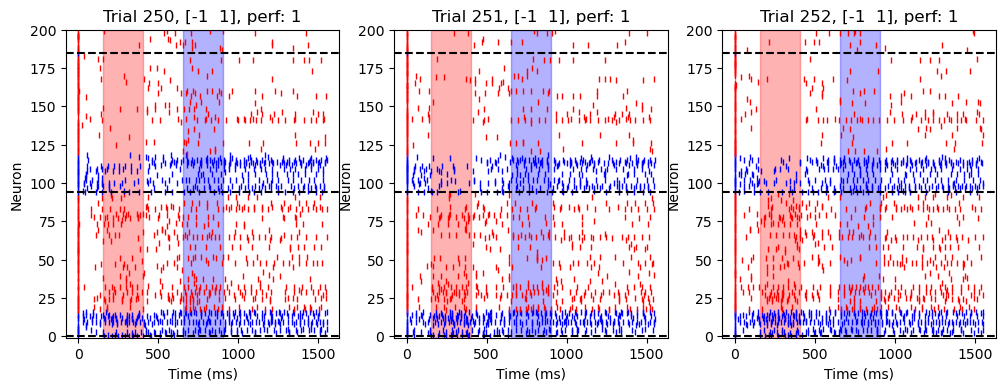

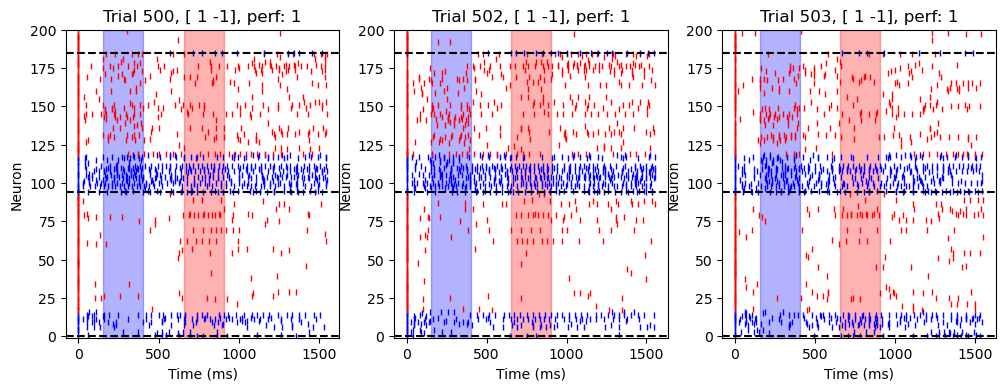

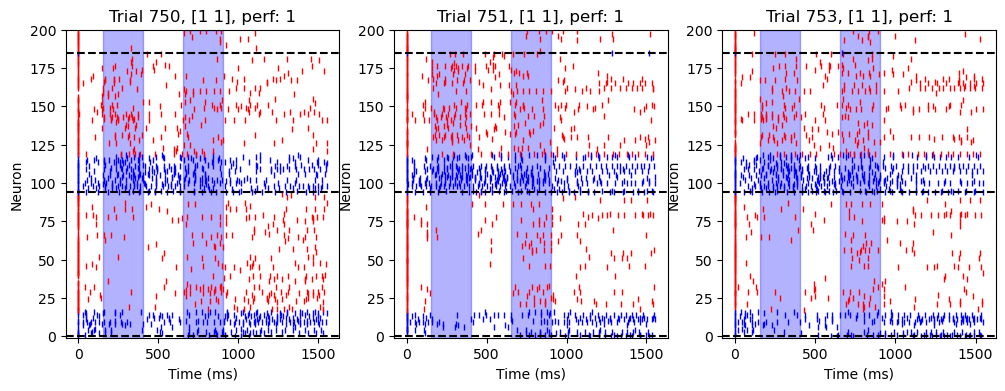

In [7]:
# plot 3 trial rasters from each trial type, all trials
importlib.reload(sn)

tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num)

# sort by tuning
sort = double_sort(tuning, exc_bool)[2]
# sort = np.argsort(tuning)
tuning_categories, hlines = np.unique(np.sort(tuning), return_index=True)

trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
for i, trial_type in enumerate(trial_types):
    trials_idx = np.where((trial_idxs == i) & (trial_perfs == 1))[0][:3]
    fig, axs = plt.subplots(1,3,figsize=(12,4))
    axs = axs.flatten()
    for j, idx in enumerate(trials_idx):
        trial_df = spk_df[spk_df['trial_id'] == idx]
        sn.plot_trial_raster(trial_df, condn_phrase, condn_num, sort=sort, 
                             ax=axs[j], hlines=hlines,)
    plt.show()


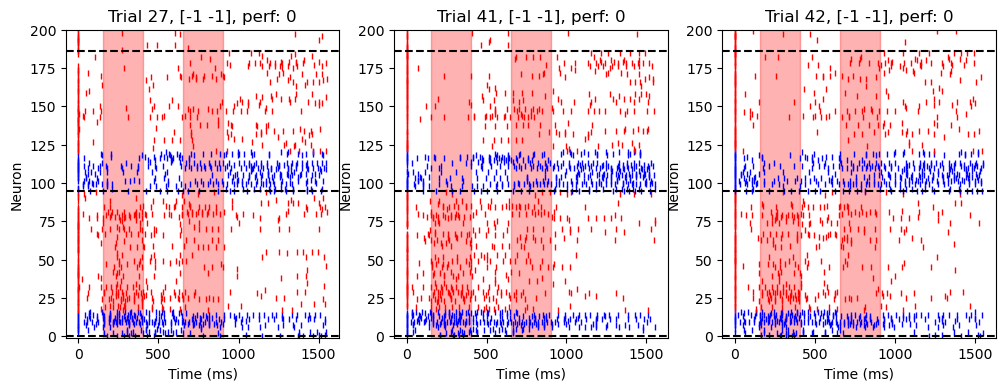

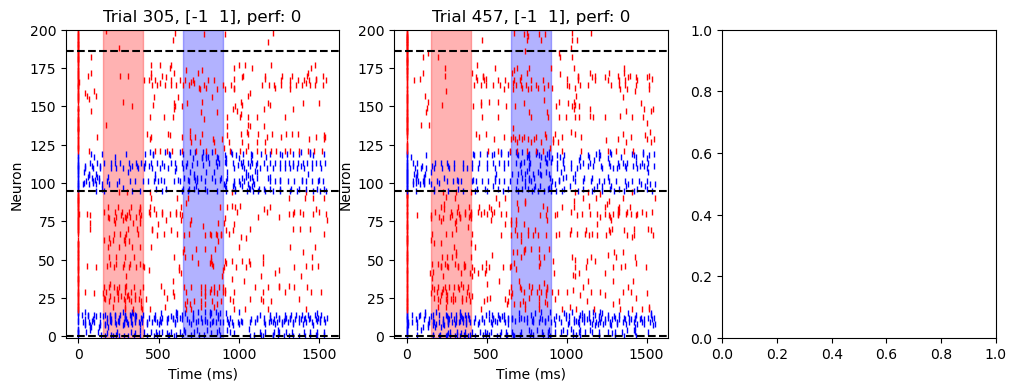

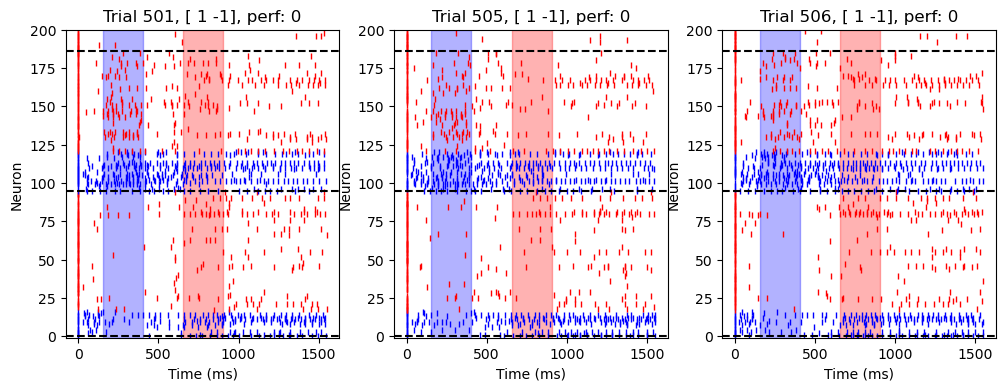

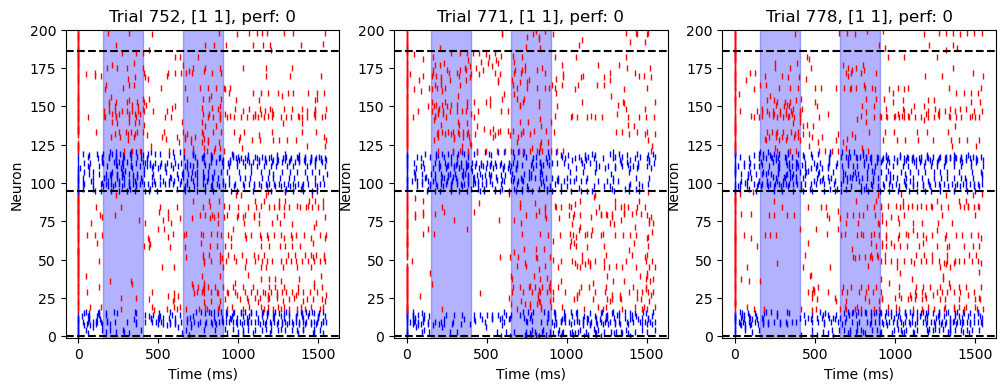

In [8]:
# plot 3 trial rasters from each trial type, incorrect only
importlib.reload(sn)

tuning = sn.calc_stim1_tuning_spikes_corr(model_name, condn_phrase, condn_num)

# sort by tuning
sort = double_sort(tuning, exc_bool)[2]
# sort = np.argsort(tuning)
tuning_categories, hlines = np.unique(np.sort(tuning), return_index=True)

trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
for i, trial_type in enumerate(trial_types):
    trials_idx = np.where((trial_idxs == i) & (trial_perfs == 0))[0][:3]
    fig, axs = plt.subplots(1,3,figsize=(12,4))
    axs = axs.flatten()
    for j, idx in enumerate(trials_idx):
        trial_df = spk_df[spk_df['trial_id'] == idx]
        sn.plot_trial_raster(trial_df, condn_phrase, condn_num, sort=sort, 
                             ax=axs[j], hlines=hlines,)
    plt.show()
